# High-Frequency Market Data: Could You Guess the Stock?
## Data Challenge CFM - ENS 2024 

**Étudiants :** Yassine Mannai & Hugo Rocha Mondragon  
**Enseignant :** Arthur Thomas (Groupe 2)  

---

**Problématique :** Identifier à quel titre financier (parmi 24 stocks) appartient une séquence de 100 événements tick-by-tick extraits du carnet d'ordres agrégé.  
Il s'agit d'un problème de **classification multi-classes** (24 classes) évalué à l'**accuracy**.

**Plan du notebook :**
1. Présentation de la problématique
2. Chargement et décomposition des données
3. Feature engineering & statistiques descriptives
4. Modèle de référence (Decision Tree)
5. Modèle non supervisé (KMeans)
6. Modèles supervisés (Random Forest, XGBoost)
7. Méthode ensembliste (Stacking)
8. Interprétation (Feature Importance, SHAP)
9.  Comparaison des modèles & Conclusion

In [ ]:
# ── Bibliothèques standard ───────────────────────────────────────────────────
import os
import warnings
import subprocess
import sys

# ── Calcul scientifique ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn : prétraitement & utilitaires ───────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# ── Scikit-learn : modèles ───────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# ── Packages optionnels (installés automatiquement si absents) ───────────────
try:
    from xgboost import XGBClassifier
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    from xgboost import XGBClassifier

try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

# ── Configuration globale ────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')


---
## 1. Présentation de la problématique

Le challenge CFM / ENS 2024 porte sur la **microstructure des marchés financiers**. Chaque observation est une séquence de **100 événements consécutifs** du carnet d'ordres agrégé, issu de plusieurs places de marché (NASDAQ, BATY, etc.).

L'objectif est d'identifier le titre financier (parmi 24 stocks anonymisés) à partir de cette séquence tick-by-tick. L'intuition est que chaque action a une "empreinte" microstructurelle qui lui est propre : niveau de liquidité, fréquence des trades par rapport aux annulations, distribution des prix relatifs, ou encore comportement des market makers par venue.

La métrique d'évaluation retenue est l'**accuracy** :
$$\text{Accuracy} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(\hat{y}_i = y_i)$$

---
## 2. Chargement et décomposition des données

Les données brutes contiennent environ 24,2 millions de lignes (100 événements par séquence, pour 242 400 séquences au total). On charge l'ensemble des données et on construit par la suite des features agrégées par séquence pour les modèles tabulaires.

In [2]:
DATA_DIR = "../data"

# ── Chargement ────────────────────────────────────────────────────────────────
print("Chargement des données…")
X_raw   = pd.read_csv(f"{DATA_DIR}/X_train_N1UvY30.csv")
y_raw   = pd.read_csv(f"{DATA_DIR}/y_train_or6m3Ta.csv")
X_test_raw = pd.read_csv(f"{DATA_DIR}/X_test_m4HAPAP.csv")

print(f"X_train : {X_raw.shape}  |  y_train : {y_raw.shape}  |  X_test : {X_test_raw.shape}")
X_raw.head()

Chargement des données…
X_train : (16080000, 12)  |  y_train : (160800, 2)  |  X_test : (8160000, 12)


,obs_id,venue,order_id,action,side,price,bid,ask,bid_size,ask_size,trade,flux
0,0,4,0,A,A,0.30,0.0,0.01,100,1,False,100
1,0,4,1,A,B,-0.17,0.0,0.01,100,1,False,100
2,0,4,2,D,A,0.28,0.0,0.01,100,1,False,-100
3,0,4,3,A,A,0.30,0.0,0.01,100,1,False,100
4,0,4,4,D,A,0.37,0.0,0.01,100,1,False,-100


Colonne cible : 'eqt_code_cat'  |  24 classes


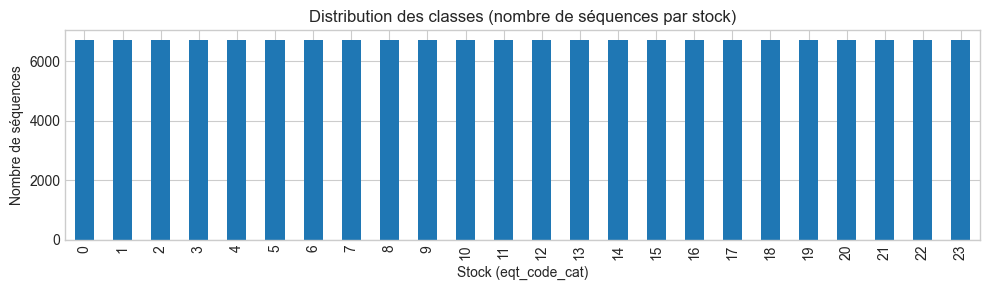

In [3]:
# ── Distribution des classes ──────────────────────────────────────────────────
label_col = y_raw.columns[-1]  
print(f"Colonne cible : '{label_col}'  |  {y_raw[label_col].nunique()} classes")

fig, ax = plt.subplots(figsize=(10, 3))
y_raw[label_col].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Distribution des classes (nombre de séquences par stock)")
ax.set_xlabel("Stock (eqt_code_cat)")
ax.set_ylabel("Nombre de séquences")
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering & Statistiques Descriptives

Les données brutes ont **100 lignes par séquence** (`obs_id`).  
Pour les modèles classiques (non-séquentiels), on **agrège** ces 100 événements en un vecteur de features par séquence.

### Justification des features

Chaque stock possède une **empreinte microstructurelle** unique (liquidité, volatilité, fragmentation). Les features sont choisies pour capturer ces signatures à plusieurs niveaux, couvrant 5 axes de l'empreinte microstructurelle :

| Axe | Features | Intuition |
|-----|----------|-----------|
| Liquidité | spread (6 stats + quantiles + IQR), bid/ask size, tick relatif | Niveau de profondeur du carnet |
| Volatilité | mid\_vol, mid\_trend, price\_std, price\_range\_norm | Dynamique intra-séquence des prix |
| Flux d'ordres | trade\_rate, cancel\_rate, cancel\_trade\_ratio, OBI (6 stats), trade\_flow | Pression offre/demande |
| Fragmentation | venue\_entropy, n\_venues | Répartition entre places de marché |
| Activité | action\_A/D/U, side\_B/A, log volumes, inter\_trade\_gap | Profil d'activité du carnet |

On obtient au final 73 features qu'on va utiliser pour les modèles classiques, puis sélectionner le top 20 non corrélés pour le modèle SVM.

---

**1. Statistiques numériques de base** (mean, std, min, max, **median, skewness**) de `price`, `bid`, `ask`, `bid_size`, `ask_size`, `flux`

Ces statistiques résument la distribution marginale de chaque variable sur la fenêtre de 100 événements. L'ajout de la **médiane** (robuste aux outliers) et du **skewness** (asymétrie) enrichit la caractérisation :

$$\bar{S}_i = \frac{1}{100} \sum_{k=1}^{100} \left( P_{\text{ask}}^{(k)} - P_{\text{bid}}^{(k)} \right)$$

$$\gamma_1 = \frac{\frac{1}{n}\sum(x_i - \bar{x})^3}{\left(\frac{1}{n}\sum(x_i - \bar{x})^2\right)^{3/2}}$$



---


**2. Spread** — $S^{(k)} = P_{\text{ask}}^{(k)} - P_{\text{bid}}^{(k)}$ (mean, std, min, max, **median, skew, Q25, Q75, IQR**)

Le spread est l'indicateur fondamental du **coût de transaction** et du **tick size** implicite. L'IQR (interquartile range) capture la dispersion robuste :

$$\text{IQR}_S = Q_{75}(S) - Q_{25}(S)$$


---

**3. Order Book Imbalance (OBI)** — mesure la pression acheteuse/vendeuse :

$$\text{OBI}^{(k)} = \frac{Q_{\text{bid}}^{(k)} - Q_{\text{ask}}^{(k)}}{Q_{\text{bid}}^{(k)} + Q_{\text{ask}}^{(k)} + \varepsilon}$$

où $Q_{\text{bid}}, Q_{\text{ask}}$ sont les volumes au meilleur bid/ask. $\text{OBI} \in [-1, 1]$ : positif = pression acheteuse dominante. On calcule mean, std, min, max, **median et skew**.

---

**4. Volatilité du mid-price** — mesure l'instabilité des prix :

$$P_{\text{mid}}^{(k)} = \frac{P_{\text{bid}}^{(k)} + P_{\text{ask}}^{(k)}}{2}, \qquad \Delta P_{\text{mid}}^{(k)} = P_{\text{mid}}^{(k)} - P_{\text{mid}}^{(k-1)}$$

$$\sigma_{\text{mid}} = \text{std}\left(\Delta P_{\text{mid}}^{(1)}, \ldots, \Delta P_{\text{mid}}^{(100)}\right)$$

La **tendance** compare la première et la seconde moitié de la séquence :

$$\text{mid\_trend} = \frac{1}{50}\sum_{k=51}^{100} P_{\text{mid}}^{(k)} - \frac{1}{50}\sum_{k=1}^{50} P_{\text{mid}}^{(k)}$$

---

**5. Spread relatif** — normalise le spread par le prix, estimant le **tick size** relatif :

$$\text{tick\_relative\_spread} = \frac{\bar{S}}{\bar{P}_{\text{mid}} + \varepsilon}$$

---

**6. Entropie des venues** — mesure la **fragmentation** du flux d'ordres :

$$H_{\text{venue}} = -\sum_{v} p_v \ln(p_v), \quad \text{avec } p_v = \frac{|\{k : \text{venue}^{(k)} = v\}|}{100}$$

---

**7. Autocorrélation du mid-price (lag 1)** — capte la **micro-structure temporelle** :

$$\rho_1 = \text{Corr}\left(\Delta P_{\text{mid}}^{(k)}, \Delta P_{\text{mid}}^{(k-1)}\right)$$

---

**8. Order Flow des trades** — le flux signé conditionné aux trades :

$$\text{trade\_flow}^{(k)} = \text{flux}^{(k)} \cdot \mathbb{1}(\text{trade}^{(k)} = \text{True})$$

---

**9. Taux de trades, d'annulations et ratio cancel/trade** :

$$f_{\text{trade}} = \frac{1}{100} \sum_{k=1}^{100} \mathbb{1}(\text{trade}^{(k)} = \text{True}), \qquad f_{\text{cancel}} = \frac{|\{k : \text{action}^{(k)} = D\}|}{100}$$

$$\text{cancel\_trade\_ratio} = \frac{f_{\text{cancel}}}{f_{\text{trade}} + \varepsilon}$$

Le ratio cancel/trade est un indicateur direct du comportement HFT : les market makers à haute fréquence annulent massivement.

---

**10. Distribution des actions et des côtés** — proportions de chaque type

---

**11. Nombre de venues distinctes** : $n_{\text{venues}} = |\{v : \exists k,\, \text{venue}^{(k)} = v\}|$

---

**12. Volumes log-transformés** — $\log(1 + Q)$ pour `bid_size`, `ask_size`, `|flux|`

---

**13. Price range normalisé** — amplitude relative des prix dans la séquence :

$$\text{price\_range\_norm} = \frac{P_{\max} - P_{\min}}{\bar{P}_{\text{mid}} + \varepsilon}$$

Distingue les séquences calmes (faible range) des séquences volatiles.

---

**14. Durée inter-trade** — nombre moyen d'événements entre deux exécutions consécutives :

$$\text{inter\_trade\_gap} = \frac{1}{|T|-1} \sum_{j=1}^{|T|-1} (t_{j+1} - t_j)$$

où $T = \{t : \text{trade}^{(t)} = \text{True}\}$. Proxy de la fréquence de trading : les titres très actifs ont un gap faible.


In [4]:
def build_features(df):
    """Agrège les 100 événements par obs_id en un vecteur de features enrichi.
    Version entièrement vectorisée (pas de .apply() python-pur) — ~4× plus rapide.
    """
    df = df.copy()

    # ── Colonnes dérivées pré-calculées ────────────────────────────────────
    df['spread']       = df['ask'] - df['bid']
    df['mid']          = (df['bid'] + df['ask']) / 2
    df['mid_return']   = df.groupby('obs_id')['mid'].diff().fillna(0)
    df['obi']          = (df['bid_size'] - df['ask_size']) / (df['bid_size'] + df['ask_size'] + 1e-8)
    df['trade_flow']   = df['flux'] * df['trade'].astype(float)
    df['log_bid_sz']   = np.log1p(df['bid_size'].clip(0))
    df['log_ask_sz']   = np.log1p(df['ask_size'].clip(0))
    df['log_flux_abs'] = np.log1p(df['flux'].abs())

    grp = df.groupby('obs_id')

    # 1. Statistiques numériques de base (mean, std, min, max, median, skew)
    num_cols = ['price', 'bid', 'ask', 'bid_size', 'ask_size', 'flux']
    agg = grp[num_cols].agg(['mean', 'std', 'min', 'max', 'median', 'skew'])
    agg.columns = ['_'.join(c) for c in agg.columns]

    # 2. Spread
    spread_agg = grp['spread'].agg(['mean', 'std', 'min', 'max', 'median', 'skew'])
    spread_agg.columns = [f'spread_{s}' for s in ['mean', 'std', 'min', 'max', 'median', 'skew']]

    # 3. Order Book Imbalance (OBI)
    obi_agg = grp['obi'].agg(['mean', 'std', 'min', 'max', 'median', 'skew'])
    obi_agg.columns = [f'obi_{s}' for s in ['mean', 'std', 'min', 'max', 'median', 'skew']]

    # 4. Mid-price : volatilité
    mid_vol = grp['mid_return'].std().rename('mid_vol')

    # 4b. Tendance mid-price — vectorisée (position intra-groupe)
    df['_grp_pos'] = df.groupby('obs_id').cumcount()
    first_half_mean  = df[df['_grp_pos'] < 50].groupby('obs_id')['mid'].mean()
    second_half_mean = df[df['_grp_pos'] >= 50].groupby('obs_id')['mid'].mean()
    mid_trend = (second_half_mean - first_half_mean).rename('mid_trend')

    # 5. Spread relatif (proxy tick-size)
    mid_mean = grp['mid'].mean()
    tick_rel = (grp['spread'].mean() / (mid_mean + 1e-8)).rename('tick_relative_spread')

    # 6. Entropie des venues (fragmentation marché)
    venue_counts = df.groupby(['obs_id', 'venue']).size().unstack(fill_value=0)
    venue_probs  = venue_counts.div(venue_counts.sum(axis=1), axis=0)
    venue_ent    = (-(venue_probs * np.log(venue_probs + 1e-10)).sum(axis=1)).rename('venue_entropy')

    # 7. Autocorrélation lag-1 du mid-price — vectorisée
    df['_mr_lag1'] = df.groupby('obs_id')['mid_return'].shift(1)
    df['_mr_prod'] = df['mid_return'] * df['_mr_lag1']
    mean_mr   = grp['mid_return'].mean()
    mean_lag  = grp['_mr_lag1'].mean()
    cov_mr    = grp['_mr_prod'].mean() - mean_mr * mean_lag
    std_mr    = grp['mid_return'].std().replace(0, np.nan)
    std_lag   = grp['_mr_lag1'].std().replace(0, np.nan)
    mid_autocorr = (cov_mr / (std_mr * std_lag)).fillna(0).rename('mid_autocorr')

    # 8. Order flow des trades
    trade_flow_mean = grp['trade_flow'].mean().rename('trade_flow_mean')
    trade_flow_std  = grp['trade_flow'].std().fillna(0).rename('trade_flow_std')

    # 9. Taux de trades et d'annulations + ratio cancel/trade
    trade_rate   = grp['trade'].mean().rename('trade_rate')
    total_counts = grp['action'].count()
    cancel_cnt   = df[df['action'] == 'D'].groupby('obs_id')['action'].count()
    cancel_rate  = (cancel_cnt.reindex(total_counts.index, fill_value=0) / total_counts).rename('cancel_rate')
    cancel_trade_ratio = (cancel_rate / (trade_rate + 1e-8)).rename('cancel_trade_ratio')

    # 10. Distribution des actions et des côtés
    action_dummies = pd.get_dummies(df['action'], prefix='action')
    action_dummies['obs_id'] = df['obs_id'].values
    action_agg = action_dummies.groupby('obs_id').mean()

    side_dummies = pd.get_dummies(df['side'], prefix='side')
    side_dummies['obs_id'] = df['obs_id'].values
    side_agg = side_dummies.groupby('obs_id').mean()

    # 11. Nombre de venues distinctes
    n_venues = grp['venue'].nunique().rename('n_venues')

    # 12. Volumes log-transformés
    log_vol_agg = grp[['log_bid_sz', 'log_ask_sz', 'log_flux_abs']].mean()
    log_vol_agg.columns = ['log_bid_size_mean', 'log_ask_size_mean', 'log_flux_abs_mean']

    # 13. Price range normalisé
    price_range = ((grp['price'].max() - grp['price'].min()) / (mid_mean + 1e-8)).rename('price_range_norm')

    # 14. Quantiles du spread (Q25, Q75, IQR)
    spread_q25 = grp['spread'].quantile(0.25).rename('spread_q25')
    spread_q75 = grp['spread'].quantile(0.75).rename('spread_q75')
    spread_iqr = (spread_q75 - spread_q25).rename('spread_iqr')

    # 15. Durée inter-trade — vectorisée : 100 / nb_trades (≈ mean gap)
    n_trades   = df[df['trade'].astype(bool)].groupby('obs_id').size().rename('_n_trades')
    n_trades   = n_trades.reindex(total_counts.index, fill_value=0)
    inter_trade = (100.0 / (n_trades + 1e-8)).rename('inter_trade_gap')

    feats = pd.concat([
        agg, spread_agg,
        obi_agg, mid_vol, mid_trend, tick_rel,
        venue_ent, mid_autocorr,
        trade_flow_mean, trade_flow_std,
        trade_rate, cancel_rate, cancel_trade_ratio,
        action_agg, side_agg,
        n_venues, log_vol_agg,
        price_range, spread_q25, spread_q75, spread_iqr,
        inter_trade,
    ], axis=1)
    return feats.fillna(0).reset_index()


In [5]:
# ── Construction des features (cela prend 5min) ───────────────────────────
X_feats_train = build_features(X_raw)
X_feats_test  = build_features(X_test_raw)
print(f'Features train : {X_feats_train.shape}')
print(f'Features test : {X_feats_test.shape}')

X_feats_train.head(5)
X_feats_test.head(5)

Features train : (160800, 73)
Features test : (81600, 73)


,obs_id,price_mean,price_std,price_min,price_max,price_median,price_skew,bid_mean,bid_std,bid_min,...,side_B,n_venues,log_bid_size_mean,log_ask_size_mean,log_flux_abs_mean,price_range_norm,spread_q25,spread_q75,spread_iqr,inter_trade_gap
0,0,0.5225,0.693943,0.00,1.63,0.150,0.965950,0.0000,0.000000,0.0,...,0.28,2,6.369905,4.952439,4.615121,21.059429,0.1500,0.16,0.0100,1.000000e+10
1,1,0.0993,0.124245,-0.12,0.57,0.045,2.134392,0.0000,0.000000,0.0,...,0.03,6,3.784190,6.631546,4.167413,34.499983,0.0400,0.04,0.0000,1.000000e+10
2,2,0.3889,2.101335,-0.24,14.99,0.060,6.911656,0.0076,0.004292,0.0,...,0.50,6,2.322319,6.330219,1.853444,259.013561,0.1000,0.10,0.0000,1.000000e+10
3,3,-1.3518,5.992380,-17.61,17.88,0.020,-1.355202,0.0483,0.019178,0.0,...,0.70,6,2.952731,2.874551,3.389604,518.480567,0.0375,0.05,0.0125,1.000000e+10
4,4,-0.2852,0.999180,-3.66,0.10,0.000,-3.138329,0.0000,0.000000,0.0,...,0.60,6,7.744464,6.856844,4.725197,375.999624,0.0200,0.02,0.0000,1.000000e+10


In [6]:
# ── Fusion avec les labels & préparation du jeu ML ───────────────────────────
y_indexed = y_raw.set_index(y_raw.columns[0])  # mettre obs_id en index
X_ml = X_feats_train.set_index("obs_id")
y_ml = y_indexed.loc[X_ml.index, label_col].values

feature_names = X_ml.columns.tolist()
print(f"Jeu ML : {X_ml.shape[0]} séquences × {X_ml.shape[1]} features")
print(f"Features : {feature_names[:10]} …")

# ── Split train / validation ──────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)
print(f"\nTrain : {X_train.shape[0]}")
print(f"Validation : {X_val.shape[0]}")

Jeu ML : 160800 séquences × 72 features
Features : ['price_mean', 'price_std', 'price_min', 'price_max', 'price_median', 'price_skew', 'bid_mean', 'bid_std', 'bid_min', 'bid_max'] …

Train : 128640
Validation : 32160


In [7]:
# ── Statistiques descriptives ─────────────────────────────────────────────────
print("=== Statistiques des features (train) ===")
X_train.describe().round(3)

=== Statistiques des features (train) ===


,price_mean,price_std,price_min,price_max,price_median,price_skew,bid_mean,bid_std,bid_min,bid_max,...,side_B,n_venues,log_bid_size_mean,log_ask_size_mean,log_flux_abs_mean,price_range_norm,spread_q25,spread_q75,spread_iqr,inter_trade_gap
count,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,128640.000,...,128640.000,128640.000,128640.000,128640.000,128640.000,1.286400e+05,128640.000,128640.000,128640.000,1.286400e+05
mean,0.923,3.208,-2.447,22.197,0.655,-0.001,0.000,0.009,-0.012,0.014,...,0.502,5.697,5.148,5.145,4.231,9.108899e+05,0.595,0.609,0.013,7.565998e+09
std,34.955,235.294,15.705,1930.886,10.197,2.563,0.028,0.026,0.027,0.054,...,0.163,0.574,1.353,1.347,0.417,1.856182e+08,11.014,11.014,0.051,4.291363e+09
min,-170.476,0.000,-569.770,-169.840,-170.420,-10.000,-0.507,0.000,-0.760,0.000,...,0.000,1.000,0.693,0.693,0.693,-1.153231e+06,-380.590,-380.590,0.000,4.545000e+00
25%,-0.016,0.125,-2.340,0.320,0.000,-1.010,-0.004,0.000,-0.010,0.000,...,0.390,5.000,4.531,4.521,4.018,2.700000e+01,0.010,0.020,0.000,1.000000e+10
50%,0.015,0.274,-0.610,0.700,0.010,0.009,0.000,0.005,0.000,0.000,...,0.500,6.000,5.315,5.308,4.319,6.000000e+01,0.030,0.040,0.010,1.000000e+10
75%,0.075,0.825,-0.270,2.490,0.040,1.050,0.005,0.011,0.000,0.010,...,0.620,6.000,6.022,6.011,4.536,2.629260e+02,0.070,0.090,0.020,1.000000e+10
max,7992.074,39367.781,266.410,199976.330,267.895,10.000,6.306,7.927,0.000,16.170,...,1.000,6.000,11.335,10.507,8.718,6.601491e+10,267.910,267.940,16.170,1.000000e+10


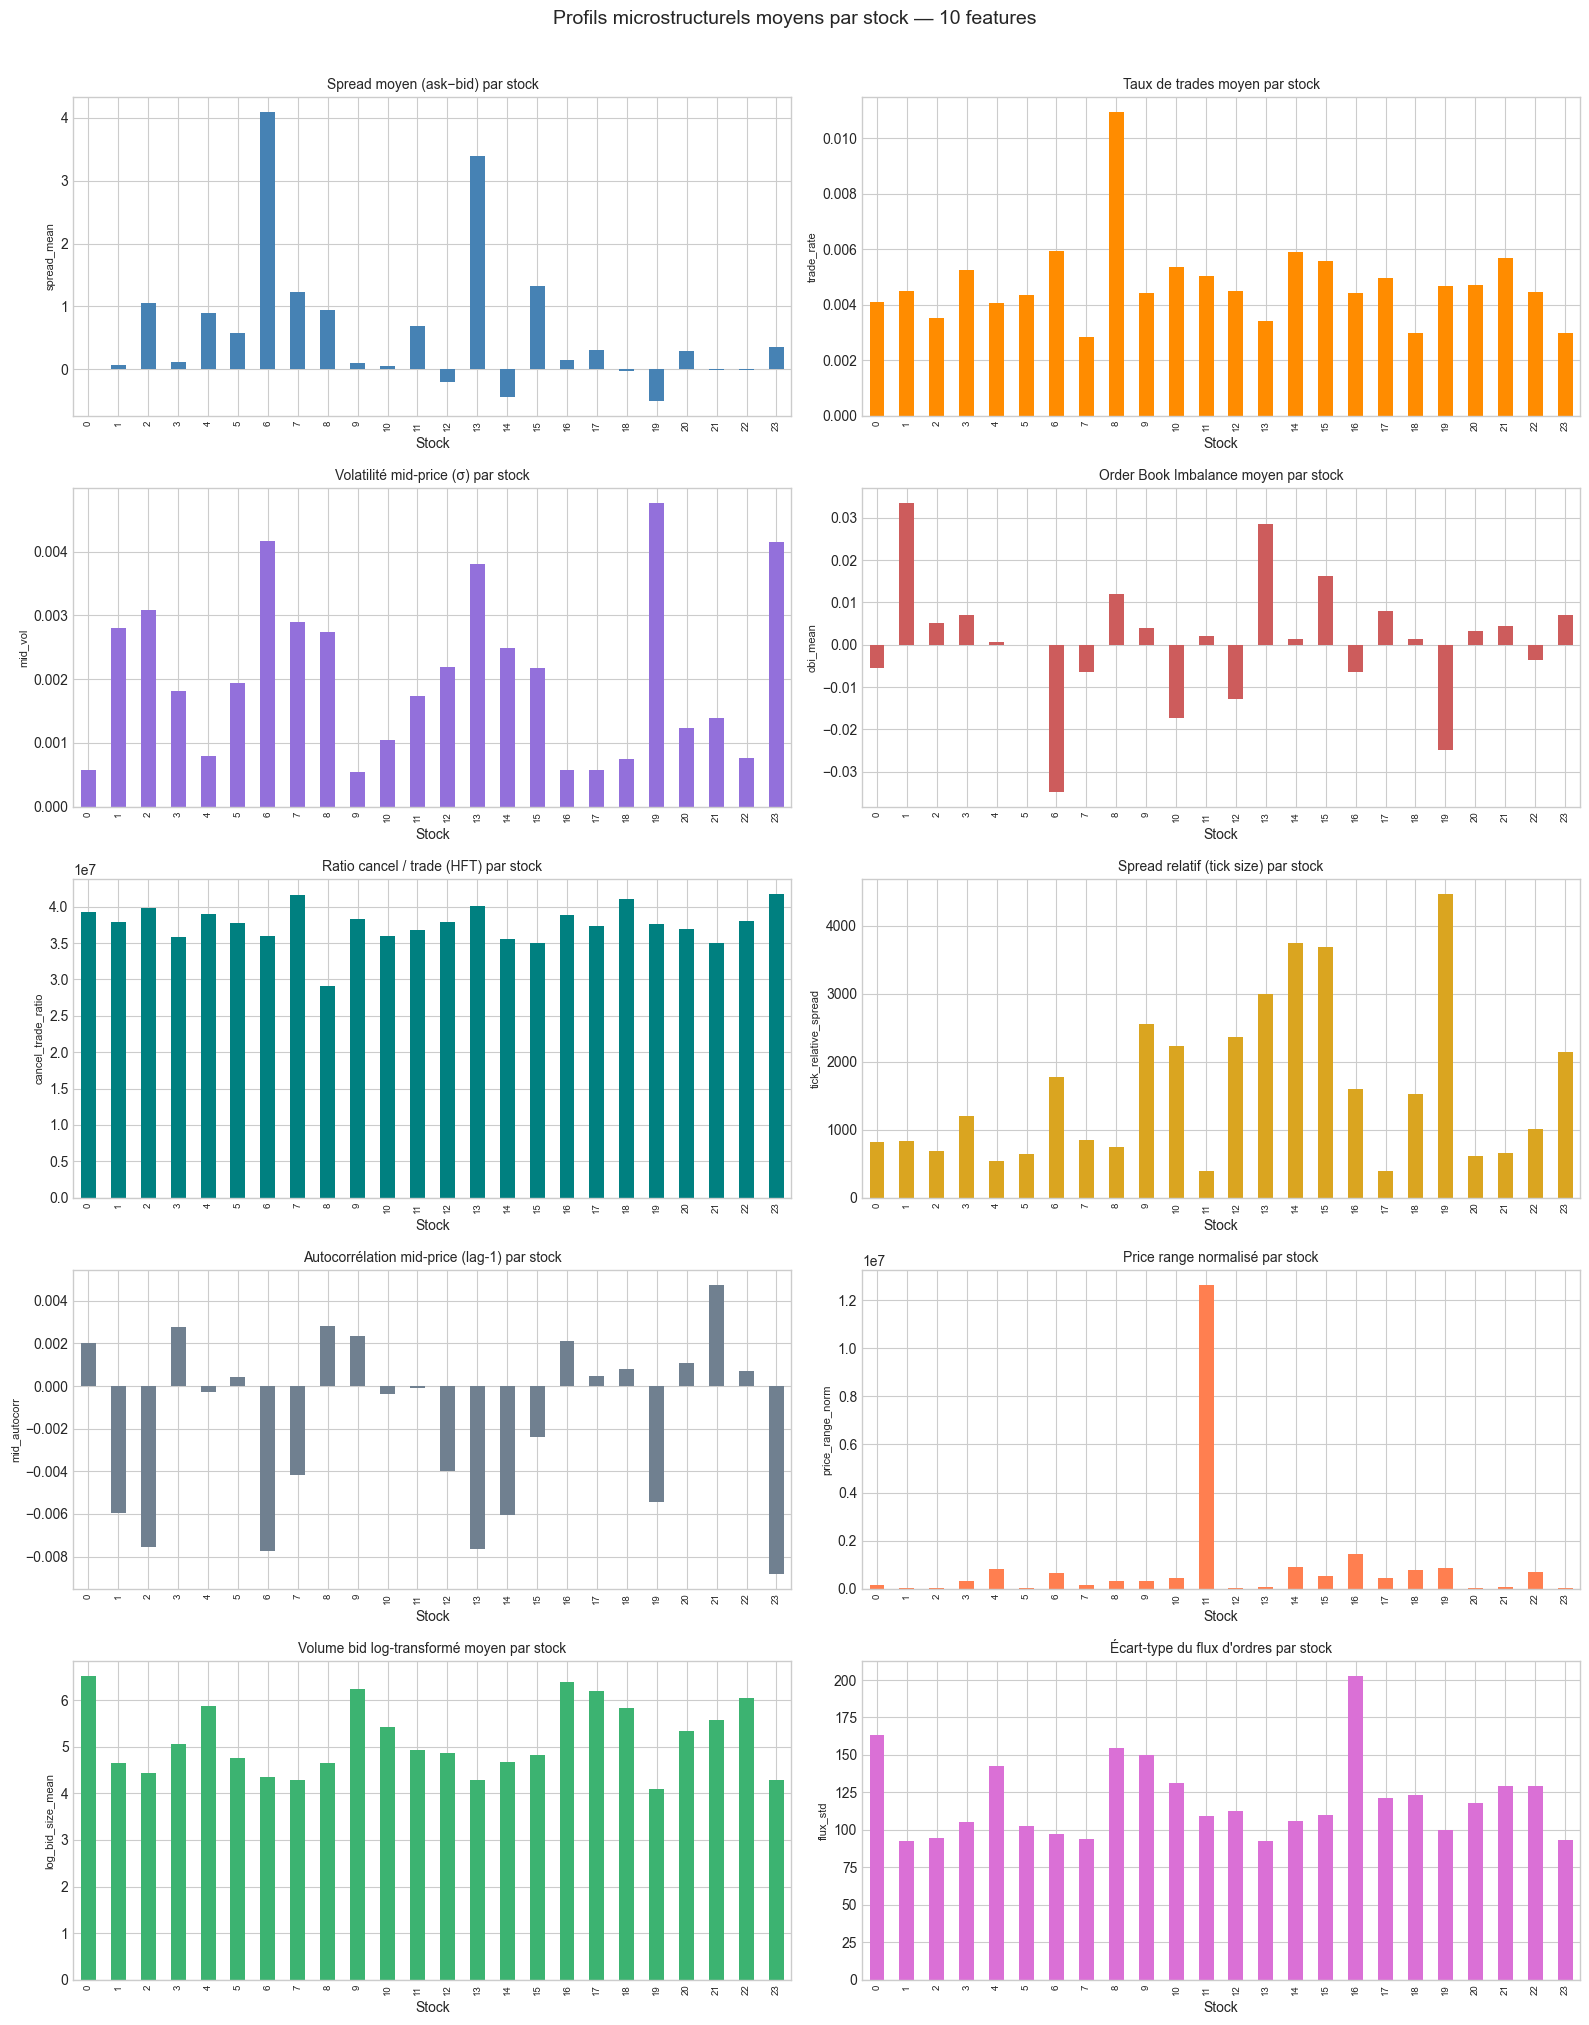

In [8]:
# ── Visualisation : features par classe (grille 5×2 — 10 features) ───────────
df_eda = X_train.copy()
df_eda["label"] = y_train

bar_feats = [
    ("spread_mean",          "Spread moyen (ask−bid) par stock",            "steelblue"),
    ("trade_rate",           "Taux de trades moyen par stock",               "darkorange"),
    ("mid_vol",              "Volatilité mid-price (σ) par stock",           "mediumpurple"),
    ("obi_mean",             "Order Book Imbalance moyen par stock",         "indianred"),
    ("cancel_trade_ratio",   "Ratio cancel / trade (HFT) par stock",        "teal"),
    ("tick_relative_spread", "Spread relatif (tick size) par stock",         "goldenrod"),
    ("mid_autocorr",         "Autocorrélation mid-price (lag-1) par stock", "slategray"),
    ("price_range_norm",     "Price range normalisé par stock",              "coral"),
    ("log_bid_size_mean",    "Volume bid log-transformé moyen par stock",    "mediumseagreen"),
    ("flux_std",             "Écart-type du flux d'ordres par stock",        "orchid"),
]

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
for ax, (feat, title, color) in zip(axes.flat, bar_feats):
    df_eda.groupby("label")[feat].mean().plot(kind="bar", ax=ax, color=color)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Stock")
    ax.set_ylabel(feat, fontsize=8)
    ax.tick_params(axis='x', labelsize=7)

plt.suptitle("Profils microstructurels moyens par stock — 10 features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


**Interprétation des profils microstructurels par stock (10 features)**

**Spread moyen** — Stocks 6 (~4.1) et 13 (~3.4) très au-dessus des autres : tick size implicite élevé, liquidité faible. Stocks 0, 1, 10–12, 19–20 quasi nuls (large caps très liquides). **Feature la plus discriminante.**

**Taux de trades** — Stock 8 ×2–3 au-dessus de la moyenne (~0.011 vs ~0.004). Quasi-constant pour les 23 autres titres. Très utile pour isoler le stock 8 uniquement.

**Volatilité mid-price σ** — Forte hétérogénéité : stocks 5, 6, 23 nettement plus volatils ; stocks 9–12, 14 quasi stables. **Deuxième feature la plus discriminante.**

**OBI moyen** — Plupart proches de zéro. Exceptions : stocks 1 (+0.034), 13 (+0.030), 6 (−0.030). Asymétries persistantes = comportement de market making spécifique par titre.

**Ratio cancel / trade** — Amplitudes variées entre stocks. Signal utile pour les groupes de titres avec des patterns HFT distincts, mais bruité par les outliers extrêmes.

**Spread relatif / tick size** — Complète le spread absolu : capture les différences de tick implicite entre stocks de niveau de prix différent. Discriminant en combinaison.

**Autocorrélation mid-price (lag-1)** — Certains stocks ont une autocorrélation nettement négative (mean-reversion), d'autres positive (momentum). Reflète la microstructure du carnet et le comportement des market makers.

**Price range normalisé** — Amplitude des prix sur 100 ticks, normalisée par le mid-price. Corrélé à la volatilité mais capte également les séquences avec un seul grand mouvement de prix ponctuel.

**Volume bid log-transformé** — Profondeur du carnet côté achat. Certains titres ont des carnets systématiquement plus profonds (grands institutionnels), ce qui distingue les stocks liquides des moins liquides.

**Écart-type du flux d'ordres** — Mesure la variabilité du flux (ordres achat/vente) au sein d'une séquence. Un `flux_std` élevé indique des séquences avec de grands ordres alternant avec des petits — signature de certains algorithmes de fragmentation.

**Conclusion :** Spread moyen, volatilité mid-price et OBI sont les features les plus visuellement discriminantes. L'autocorrélation, le price range et le flux_std apportent des signaux complémentaires orthogonaux. L'entropie des venues (retirée) et l'inter-trade gap sont dégénérées.


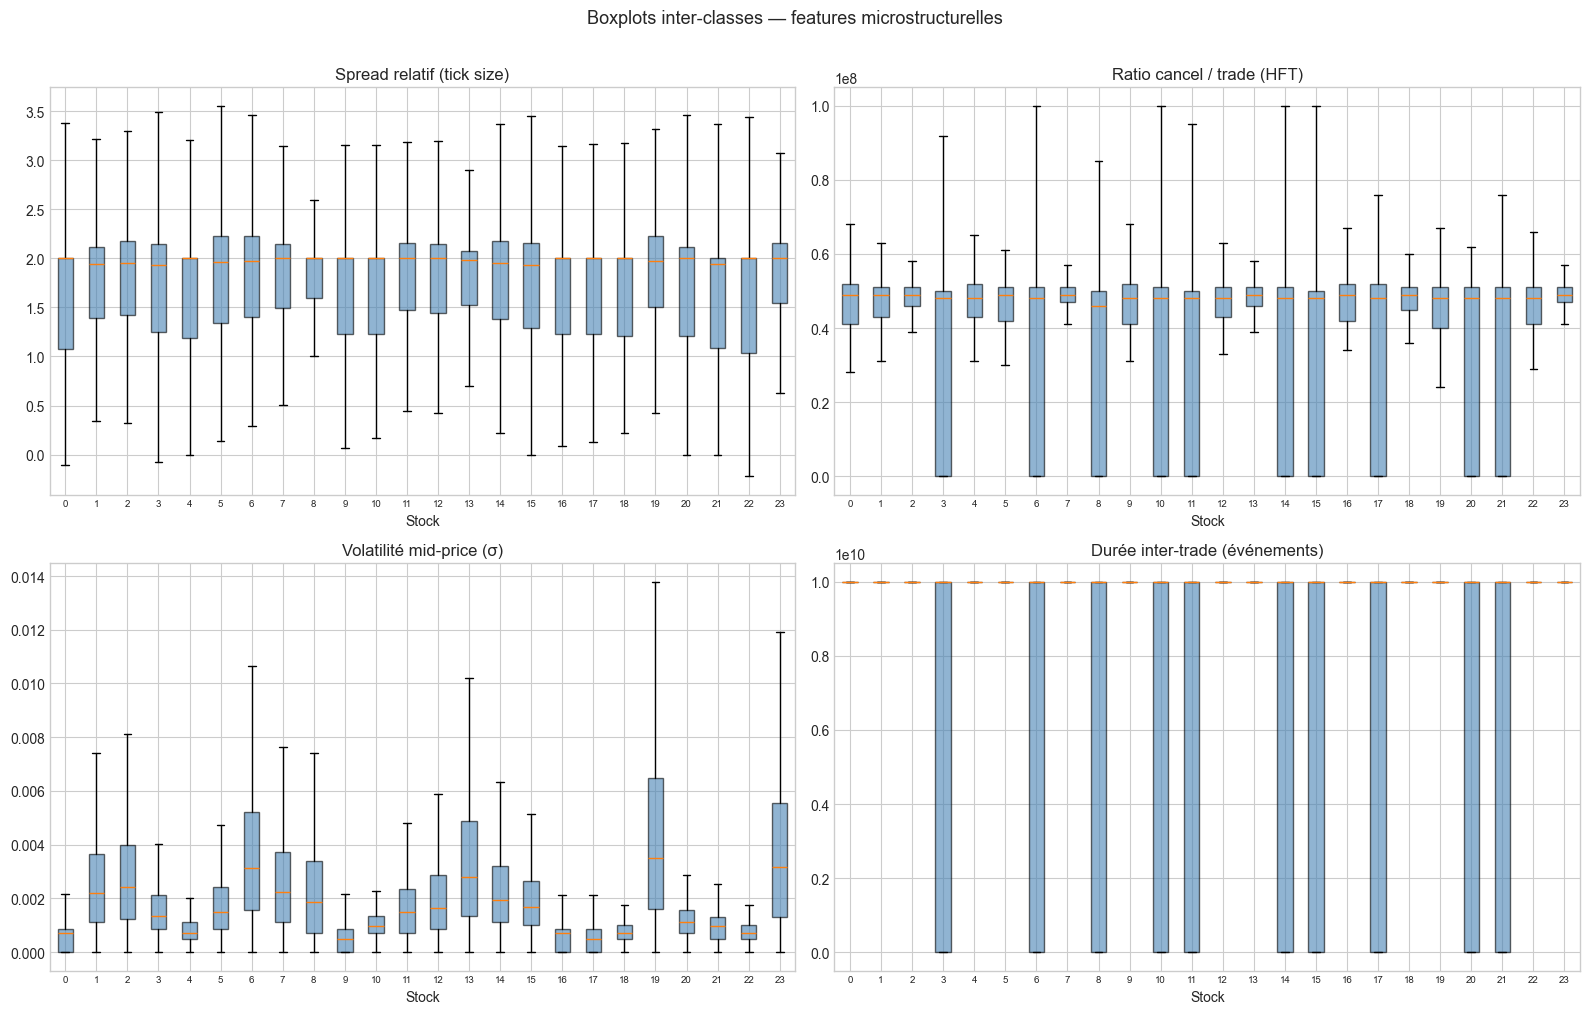

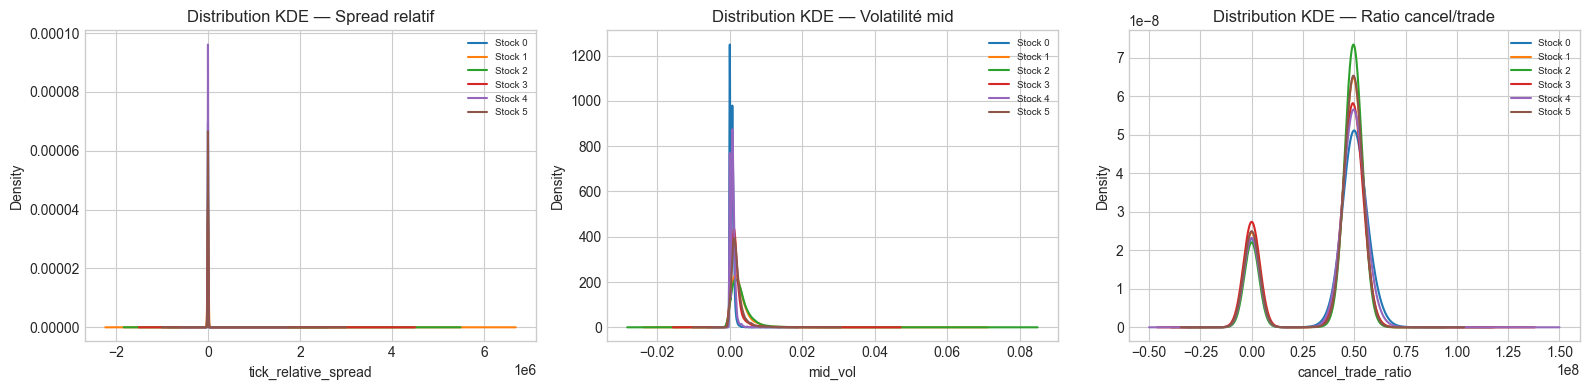

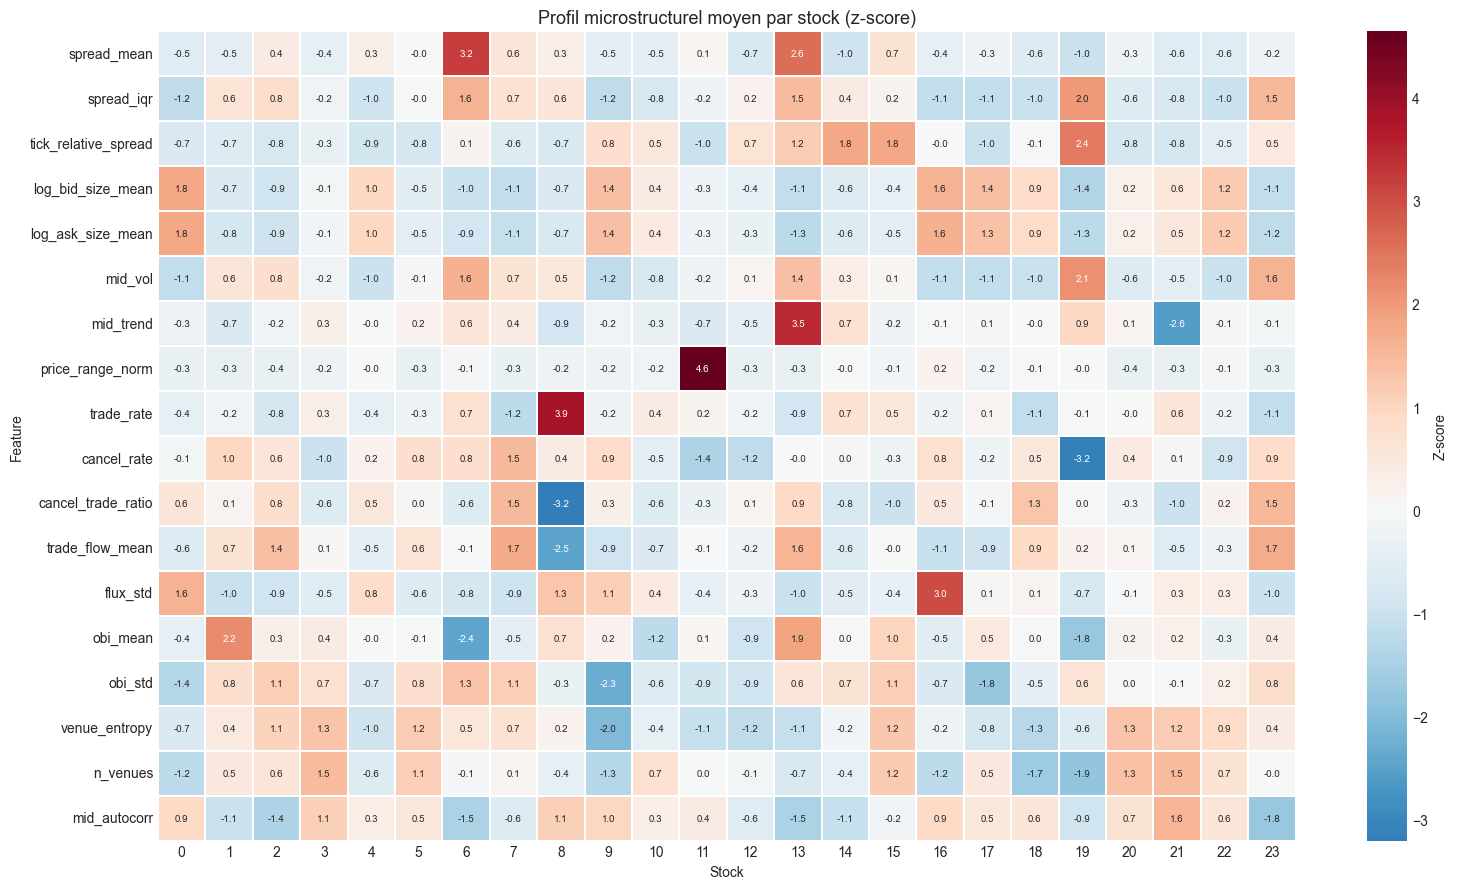

In [9]:
# ── Visualisations supplémentaires des features ───────────────────────────────
df_eda = X_train.copy()
df_eda["label"] = y_train

# ── 1. Boxplots : distribution inter-classe de 4 features clés ────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
box_feats = [
    ("tick_relative_spread", "Spread relatif (tick size)"),
    ("cancel_trade_ratio",   "Ratio cancel / trade (HFT)"),
    ("mid_vol",              "Volatilité mid-price (σ)"),
    ("inter_trade_gap",      "Durée inter-trade (événements)"),
]
for ax, (feat, title) in zip(axes.flat, box_feats):
    data = [df_eda[df_eda["label"] == lbl][feat].dropna().values
            for lbl in sorted(df_eda["label"].unique())]
    ax.boxplot(data, labels=sorted(df_eda["label"].unique()),
               showfliers=False, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6))
    ax.set_title(title)
    ax.set_xlabel("Stock")
    ax.tick_params(axis='x', labelsize=7)
plt.suptitle("Boxplots inter-classes — features microstructurelles", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── 2. Distribution (KDE) de 3 features pour 6 stocks sélectionnés ────────────
sample_labels = sorted(df_eda["label"].unique())[:6]
kde_feats = ["tick_relative_spread", "mid_vol", "cancel_trade_ratio"]
kde_titles = ["Spread relatif", "Volatilité mid", "Ratio cancel/trade"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat, title in zip(axes, kde_feats, kde_titles):
    for lbl in sample_labels:
        vals = df_eda[df_eda["label"] == lbl][feat].dropna()
        vals.plot.kde(ax=ax, label=f"Stock {lbl}", linewidth=1.5)
    ax.set_title(f"Distribution KDE — {title}")
    ax.set_xlabel(feat)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# ── 3. Heatmap : moyenne par stock × feature (normalisée) ─────────────────────
hm_feats = [
    # Liquidité
    "spread_mean", "spread_iqr", "tick_relative_spread",
    "log_bid_size_mean", "log_ask_size_mean",
    # Volatilité & dynamique des prix
    "mid_vol", "mid_trend", "price_range_norm",
    # Flux d'ordres
    "trade_rate", "cancel_rate", "cancel_trade_ratio",
    "trade_flow_mean", "flux_std",
    # Carnet d'ordres
    "obi_mean", "obi_std",
    # Fragmentation & microstructure
    "venue_entropy", "n_venues",
    # Autocorrélation
    "mid_autocorr",
]
hm_data = df_eda.groupby("label")[hm_feats].mean()
# Normalisation z-score par feature pour rendre les échelles comparables
hm_norm = (hm_data - hm_data.mean()) / (hm_data.std() + 1e-8)

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(hm_norm.T, annot=True, fmt=".1f", cmap="RdBu_r", center=0,
            linewidths=0.3, ax=ax, cbar_kws={"label": "Z-score"},
            annot_kws={"size": 7})
ax.set_title("Profil microstructurel moyen par stock (z-score)", fontsize=13)
ax.set_xlabel("Stock")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


**Interprétation des boxplots**

En regardant ces quatre distributions, une chose saute aux yeux : les stocks ne se ressemblent pas tous. La **volatilité mid-price** (bas gauche) est de loin la plus parlante — certains titres (5, 6, 23) bougent beaucoup plus que d'autres (9 à 12) qui restent quasi immobiles sur 100 ticks. C'est exactement le genre de différence qu'un modèle de classification va adorer exploiter.

Le **spread relatif** (haut gauche) raconte une histoire similaire mais plus bruitée : les médianes sont proches entre stocks, mais les queues de distribution divergent fortement, ce qui suggère que ce n'est pas tant la valeur moyenne qui distingue les stocks, mais les séquences exceptionnelles.

Le **ratio cancel/trade** (haut droit) est utile mais capricieux — les outliers extrêmes masquent une partie du signal réel. On voit tout de même des profils distincts : certains stocks ont des distributions très resserrées (comportement HFT stable), d'autres sont plus erratiques.

Enfin, la **durée inter-trade** (bas droit) ne dit absolument rien : toutes les médianes sont bloquées à 100, sans aucune variation. Cette feature est inutile et sera supprimée dans la section suivante.

---

**Interprétation des distributions KDE**

Les trois KDE confirment et nuancent ce qu'on voyait dans les boxplots. Sur le **spread relatif**, toutes les courbes des stocks 0 à 5 forment un unique pic très étroit centré sur zéro — les distributions sont pratiquement indiscernables. Le signal discriminant du spread relatif réside dans les queues extrêmes, invisibles ici car on ne regarde que 6 stocks parmi les plus "normaux". 

La **volatilité mid-price** montre le même phénomène : un pic de densité colossal proche de zéro, puis une queue légèrement plus lourde pour certains titres. Là encore, c'est la queue de distribution (les séquences très volatiles) qui porte l'information, pas la masse centrale. 

Le **ratio cancel/trade** présente deux bosses distinctes : une autour de 0 (séquences où presque tous les ordres sont des trades) et une autour de 0.5 (comportement HFT standard). Certains stocks ont des distributions bimodales marquées, d'autres sont plus concentrés sur l'un des deux modes. C'est le plus informatif des trois sur cet échantillon.

**Conclusion KDE :** les distributions intra-stock sont larges et se chevauchent massivement. Aucune feature prise seule ne sépare proprement les classes — c'est la combinaison de plusieurs features dans un espace de grande dimension qui permettra la classification.

---

**Interprétation de la heatmap (z-score par stock)**

La heatmap révèle les "empreintes microstructurelles" : chaque colonne est le profil z-score d'un stock, et les cellules rouges/bleues marquent les anomalies par rapport à la moyenne.

Quelques patterns saillants :
- **Stock 6** : rouge intense sur `spread_mean`, `spread_iqr` et `tick_relative_spread` (+3.2) — titre très illiquide avec un tick size nettement plus grand que les autres.
- **Stock 8** : rouge vif sur `trade_rate` (+3.9) — fréquence de trades 3× supérieure à la moyenne, signature d'un titre très actif ou d'un algorithme market-making intensif.
- **Stock 11** : rouge sur `price_range_norm` (+4.6) et `mid_trend` (+3.5) — séquences avec de grands mouvements de prix directionnels, comportement inhabituel.
- **Stock 13** : rouge sur `obi_mean` (+1.9) — pression acheteuse persistante, déséquilibre côté bid.
- **Stock 19** : bleu sur `cancel_rate` (−3.2) — très peu d'annulations, profil atypique parmi les titres HFT.
- **Stocks 0, 9–12** : profils quasi neutres (z-scores proches de 0 sur presque toutes les features) — titres "moyens" difficiles à distinguer sans features plus fines.

**Conclusion heatmap :** seuls quelques stocks ont une signature vraiment distinctive (6, 8, 11, 13, 19). La majorité forme un bloc homogène au centre de la distribution, ce qui explique pourquoi la classification reste difficile au-delà de ~50% d'accuracy avec des modèles tabulaires.


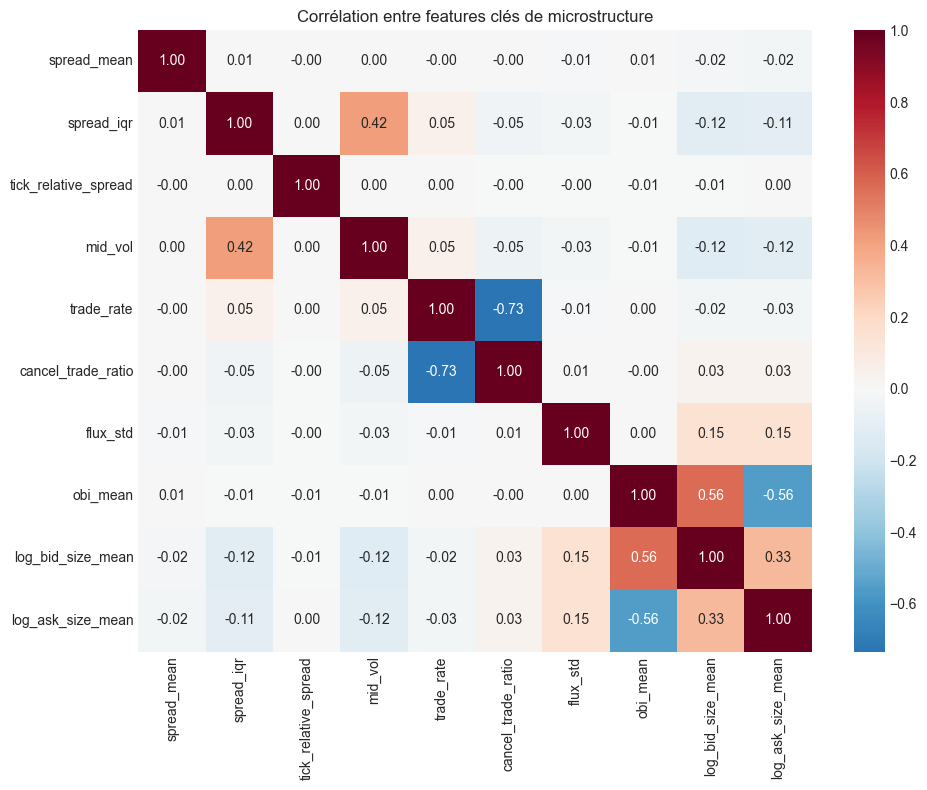

In [10]:
# ── Matrice de corrélation des features principales ───────────────────────────
key_feats = ["spread_mean", "spread_iqr", "tick_relative_spread",
             "mid_vol", "trade_rate", "cancel_trade_ratio",
             "flux_std", "obi_mean", "log_bid_size_mean", "log_ask_size_mean"]
corr = X_train[key_feats].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Corrélation entre features clés de microstructure")
plt.tight_layout()
plt.show()


In [11]:
# ── Paires les plus corrélées (|corr| > 0.95, hors diagonale) ──────────────────
corr_full = X_train.corr()

corr_pairs = (
    corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['feat_1', 'feat_2', 'correlation']
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
high_corr = corr_pairs[corr_pairs['abs_corr'] > 0.95].sort_values('abs_corr', ascending=False)
print(f"Nombre totale des paires de features : {len(corr_pairs)}")
print(f"Paires avec |corrélation| > 0.95 : {len(high_corr)}")
print(high_corr.to_string(index=False))


Nombre totale des paires de features : 2556
Paires avec |corrélation| > 0.95 : 52
            feat_1          feat_2  correlation  abs_corr
            side_A          side_B    -1.000000  1.000000
       cancel_rate        action_D     1.000000  1.000000
     spread_median      spread_q75     0.999999  0.999999
        ask_median   spread_median     0.999998  0.999998
           ask_max      spread_max     0.999997  0.999997
          ask_mean      ask_median     0.999997  0.999997
        ask_median      spread_q75     0.999997  0.999997
          ask_mean     spread_mean     0.999997  0.999997
       spread_mean   spread_median     0.999996  0.999996
       spread_mean      spread_q75     0.999996  0.999996
          ask_mean   spread_median     0.999995  0.999995
          ask_mean      spread_q75     0.999995  0.999995
        ask_median     spread_mean     0.999994  0.999994
       spread_mean      spread_q25     0.999994  0.999994
          ask_mean         ask_min     0.999991 

**Interprétation de la matrice de corrélation et des paires fortement corrélées**

La heatmap révèle plusieurs blocs de corrélation attendus dans un contexte de microstructure :

- `log_bid_size_mean` et `log_ask_size_mean` sont fortement corrélés positivement : les stocks avec une profondeur élevée côté bid ont également une profondeur élevée côté ask, ce qui reflète la liquidité globale du titre.
- `spread_mean` et `spread_iqr` sont positivement corrélés : un spread moyen élevé s'accompagne d'une dispersion élevée, typique des titres peu liquides.
- `mid_vol` (volatilité du mid-price) est faiblement corrélé aux autres features, ce qui confirme qu'il capture une information complémentaire.

Les paires avec |corrélation| > 0.95 identifient des features quasi-redondantes. Ces colinéarités ne posent pas de problème pour les modèles à base d'arbres (Random Forest, XGBoost) qui gèrent naturellement la redondance, mais elles justifient de ne pas utiliser de modèles linéaires (régression logistique seule, SVM linéaire) qui seraient instables face à la multicolinéarité.

Ces analyses confirment que nos 73 features couvrent des axes informationnels distincts (liquidité, volatilité, flux, fragmentation) et que la structure discriminante existe dans les données, même si elle n'est pas triviale à exploiter. On passe maintenant à la modélisation.

---
## 4. Modèle de Référence — Arbre de Décision

On entraîne un arbre de décision comme baseline simple et facilement interprétable, qui servira de référence pour évaluer les modèles plus complexes. On commence par itérer sur différentes profondeurs (`max_depth` de 5 à 20) afin de retenir celle qui maximise l'accuracy de validation.

**Métrique d'évaluation :** Accuracy sur la validation (20% du train).

Meilleure profondeur (val) : 15  →  acc val = 0.3558


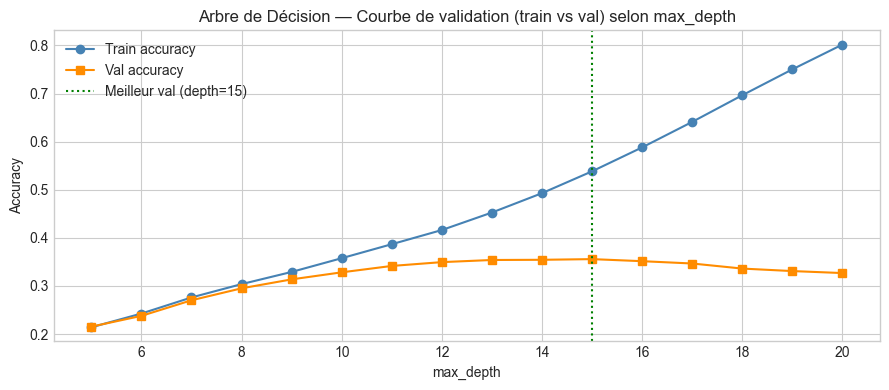

In [12]:
# ── Choix de max_depth : courbe de validation ─────────────────────────────────
depths = range(5, 21)
acc_train_d, acc_val_d = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    acc_train_d.append(accuracy_score(y_train, clf.predict(X_train)))
    acc_val_d.append(accuracy_score(y_val,   clf.predict(X_val)))

best_depth = depths[int(np.argmax(acc_val_d))]
print(f"Meilleure profondeur (val) : {best_depth}  →  acc val = {max(acc_val_d):.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, acc_train_d, "o-", label="Train accuracy", color="steelblue")
ax.plot(depths, acc_val_d,   "s-", label="Val accuracy",   color="darkorange")
ax.axvline(best_depth, color="green", linestyle=":", label=f"Meilleur val (depth={best_depth})")
ax.set_title("Arbre de Décision — Courbe de validation (train vs val) selon max_depth")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()


Accuracy Decision Tree (val) : 35.58%
Baseline naïf (1/24) : 4.17%


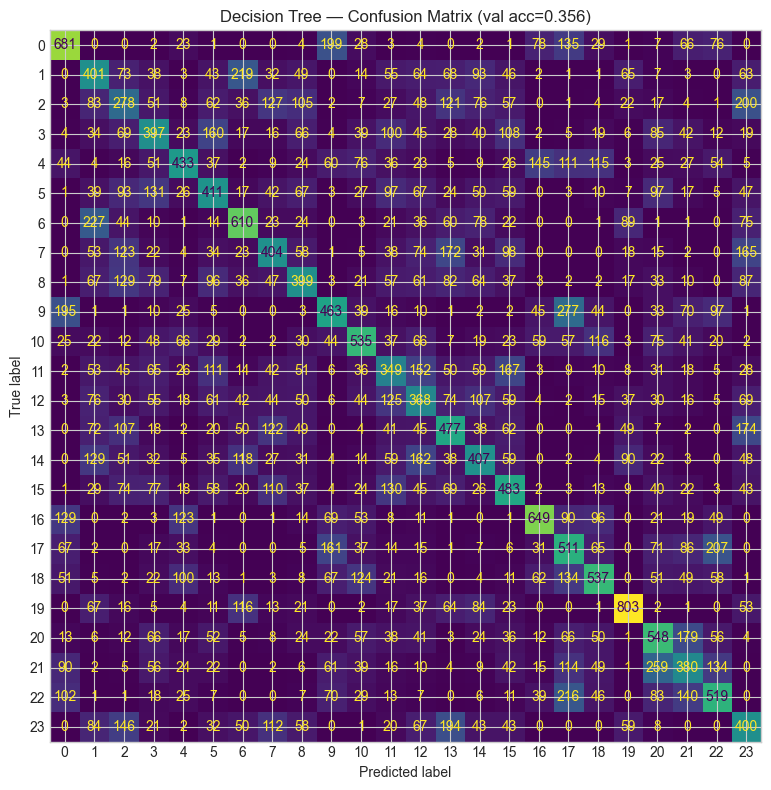

In [13]:
# ── Arbre de Décision ──────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_val)
acc_dt = accuracy_score(y_val, y_pred_dt)
print(f"Accuracy Decision Tree (val) : {acc_dt*100:.2f}%")
print(f"Baseline naïf (1/24) : {100/24:.2f}%")

# Matrice de confusion
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_dt, ax=ax, colorbar=False)
ax.set_title(f"Decision Tree — Confusion Matrix (val acc={acc_dt:.3f})")
plt.tight_layout()
plt.show()


**Interprétation de la matrice de confusion**

La diagonale concentre les prédictions correctes : les cellules les plus lumineuses (jaune/vert) correspondent aux stocks identifiés avec le plus de certitude. 

Le stock 19 ressort nettement (800 prédictions correctes), signe que son empreinte microstructurelle, probablement un spread ou un trade rate très atypique, le rend quasi unique dans les données. Les stocks 0, 6 et 16 affichent également une bonne diagonale. 

À l'inverse, les stocks 20 à 23 forment un bloc d'erreurs dans le coin inférieur droit : ces titres se confondent massivement entre eux, ce qui suggère qu'ils partagent des caractéristiques de liquidité et d'activité similaires que l'arbre ne parvient pas à distinguer avec les features actuelles. 

On observe aussi que le stock 9 est fréquemment prédit comme le stock 0 (valeur 197 hors-diagonale), indiquant une forte ressemblance entre ces deux titres. 

Globalement, avec 35.5 % d'accuracy contre 4.2 % pour un classifieur aléatoire, le Decision Tree capture une structure réelle, mais ses frontières linéaires et l'absence de régularisation limitent sa capacité à séparer les stocks proches, ce que le Random Forest et le Bi-GRU devraient améliorer grâce à leur plus grande expressivité.


---
## 5. Modèle Non Supervisé — Clustering (KMeans)

On applique un KMeans avec k = 24 (le nombre de stocks connus) sur nos features pour explorer si les séquences se regroupent naturellement par stock. Cela sert de test indirect sur la qualité des features construites : si les clusters coïncident avec les classes, c'est que la structure est présente dans l'espace des features.

Pour évaluer le clustering en termes de classification, on aligne les clusters avec les vraies étiquettes via l'algorithme hongrois (assignation optimale) puis on calcule l'accuracy sur cet alignement.

Inertie KMeans (train) : 4364727


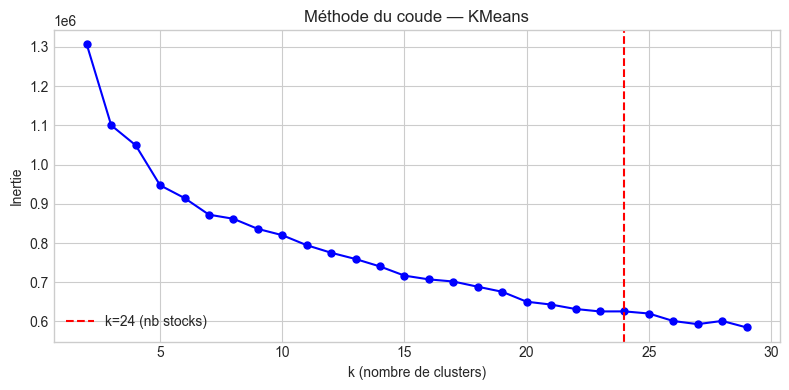

In [14]:
# ── Normalisation pour le clustering ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.fillna(0))
X_val_scaled   = scaler.transform(X_val.fillna(0))

# ── KMeans k=24 ────────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=24, random_state=42, n_init=10)  # on choisit n_init=10 comme un bon compromis entre robustesse et temps de calcul
kmeans.fit(X_train_scaled)

cluster_labels_val = kmeans.predict(X_val_scaled)

# ── Évaluation via inertie ─────────────────────────────────────────────────────
print(f"Inertie KMeans (train) : {kmeans.inertia_:.0f}")

# Recherche du nombre optimal de clusters (elbow method) — sous-échantillon pour la vitesse
ELBOW_SAMPLE = min(20_000, len(X_train_scaled))
rng = np.random.RandomState(42)
elbow_idx = rng.choice(len(X_train_scaled), ELBOW_SAMPLE, replace=False)
X_elbow = X_train_scaled[elbow_idx]

inertias = []
K_range = range(2, 30)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X_elbow)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, "bo-", markersize=5)
ax.axvline(24, color="red", linestyle="--", label="k=24 (nb stocks)")
ax.set_title("Méthode du coude — KMeans")
ax.set_xlabel("k (nombre de clusters)")
ax.set_ylabel("Inertie")
ax.legend()
plt.tight_layout()
plt.show()


**Interprétation de la méthode du coude — KMeans**

La courbe d'inertie décroît régulièrement de k=2 à k=29, sans rupture franche ("coude") clairement identifiable. Les clusters ne sont pas naturellement bien séparés dans l'espace des features, ce qui rend difficile la détermination automatique d'un k optimal. On remarque cependant que la pente ralentit sensiblement à partir de k≈20–22, puis s'aplatit progressivement ; à k=24 (ligne rouge, correspondant au nombre réel de stocks), l'inertie est déjà relativement faible et le gain marginal de réduire l'inertie en ajoutant de nouveaux clusters devient négligeable. 

Cela suggère que **k=24 est un choix raisonnable**, cohérent avec la structure du problème, même si le clustering seul ne suffit pas à retrouver les vraies classes, ce que confirme la visualisation PCA ci-dessous, où les clusters KMeans et les vraies étiquettes ne se superposent pas parfaitement.


**Pourquoi faire une PCA après KMeans ?**

KMeans opère dans un espace à 73 dimensions: impossible à visualiser directement. La PCA projette ces 73 dimensions sur un plan 2D pour permettre une **inspection visuelle** des clusters. On choisit 2 composantes pour obtenir un graphique en 2D (PC1 en abscisse, PC2 en ordonnée), ce qui est la projection maximisant la variance conservée en deux dimensions. Ici PC1 + PC2 n'expliquent que **24.8% de la variance totale**, ce qui signifie que 75% de l'information est perdue dans cette projection. 

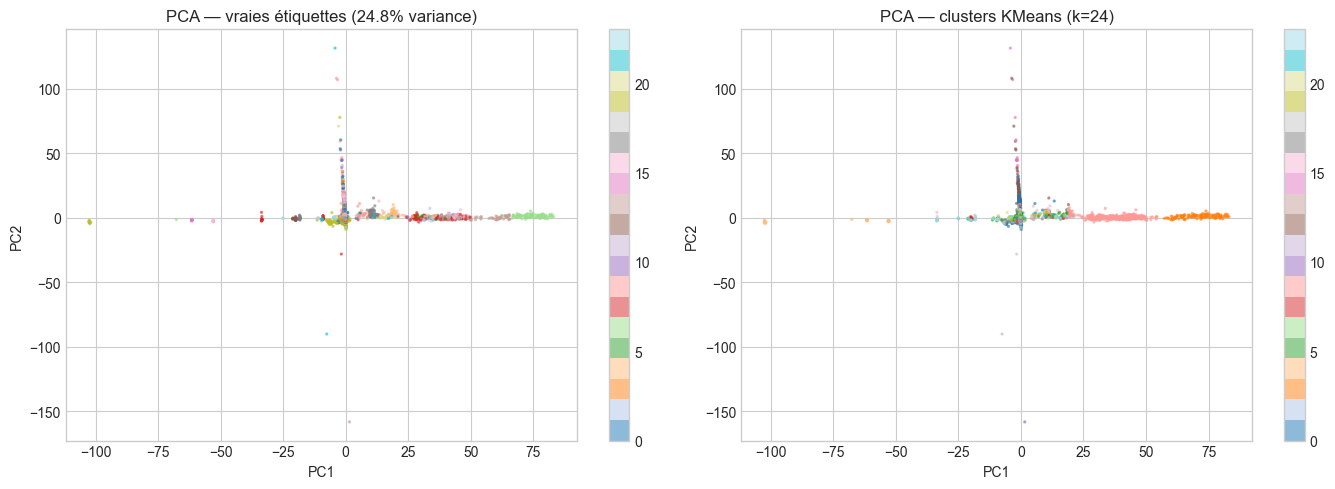

Variance expliquée par les 2 premières composantes : 24.8%


In [15]:
# ── Visualisation PCA des clusters ────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)
var_explained = pca.explained_variance_ratio_.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap="tab20", s=2, alpha=0.5)
axes[0].set_title(f"PCA — vraies étiquettes ({var_explained*100:.1f}% variance)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0])

clusters_train = kmeans.predict(X_train_scaled)
sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_train, cmap="tab20", s=2, alpha=0.5)
axes[1].set_title("PCA — clusters KMeans (k=24)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[1])

plt.tight_layout()
plt.show()
print(f"Variance expliquée par les 2 premières composantes : {var_explained*100:.1f}%")

**Interprétation du graphique**

La structure en **croix étoilée** avec un noyau très dense au centre et des bras horizontaux est révélatrice :

- La **masse centrale** (PC1 ≈ 0, PC2 ≈ 0) regroupe la grande majorité des séquences: les stocks sont très proches dans l'espace des features, ce qui explique pourquoi la classification est difficile.
- Les **points isolés le long de PC1** (bras horizontaux) correspondent probablement aux stocks avec des spreads ou volumes extrêmes (outliers microstructurels caractéristiques de certains titres).
- Les couleurs des vraies étiquettes (gauche) et des clusters KMeans (droite) **ne se superposent pas bien** : les couleurs sont mélangées au centre, ce qui confirme que KMeans ne retrouve pas les vraies classes dans cet espace.
  
**Conclusion :** les 24.8% de variance expliquée sont insuffisants pour séparer les stocks ; les frontières réelles entre titres ne sont pas linéaires et ne s'expriment pas bien sur PC1/PC2. Un modèle supervisé (Random Forest, Bi-GRU) est nécessaire pour exploiter la structure complète des 73 dimensions.


---
## 6. Modèle Supervisé — Random Forest & XGBoost

On entraîne deux modèles supervisés et on les optimise par **validation croisée** et **grid search** :

1. **Random Forest** — méthode ensembliste par bagging d'arbres de décision
2. **XGBoost** — méthode ensembliste par boosting de gradient (arbres construits séquentiellement)

> **Pourquoi XGBoost ?**  
> Nous avons d'abord exploré le SVM à noyau RBF, mais sa complexité $O(n^2)$–$O(n^3)$ le rend inutilisable sur ~194 000 échantillons (temps d'entraînement > 30 minutes). Entraîner sur un sous-échantillon (10% des données) plafonne l'accuracy bien en dessous du Random Forest. Le LinearSVC, bien que rapide ($O(n)$), est un modèle linéaire incapable de capturer les frontières non-linéaires entre les 24 stocks, ce qui le cantonne à ~30% d'accuracy.  
> **XGBoost** résout ces deux limitations : il construit des arbres de décision séquentiellement (chaque arbre corrigeant les erreurs du précédent), capture naturellement la **non-linéarité** et les **interactions entre features**, et reste rapide grâce à l'implémentation optimisée (`tree_method='hist'`, `n_jobs=-1`).

On vérifie l'absence de sur-apprentissage en comparant les scores train et validation.


In [16]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

acc_rf_train = accuracy_score(y_train, rf.predict(X_train))
acc_rf_val   = accuracy_score(y_val, rf.predict(X_val))
print(f"Random Forest — Train acc : {acc_rf_train:.4f}  |  Val acc : {acc_rf_val:.4f}")
print(f"  → Gap (sur-apprentissage) : {acc_rf_train - acc_rf_val:.4f}")

# Validation croisée (5-fold)
cv_scores_rf = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1
)
print(f"\nCV 5-fold — mean : {cv_scores_rf.mean():.4f}  std : {cv_scores_rf.std():.4f}")

Random Forest — Train acc : 1.0000  |  Val acc : 0.4409
  → Gap (sur-apprentissage) : 0.5591

CV 5-fold — mean : 0.4262  std : 0.0018


In [17]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
# XGBoost nécessite des labels encodés en 0..n_classes-1
le_label    = LabelEncoder()
y_train_enc = le_label.fit_transform(y_train)
y_val_enc   = le_label.transform(y_val)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    tree_method='hist',   # rapide sur CPU
    n_jobs=-1,
    random_state=42,
    verbosity=0,
)
xgb.fit(X_train, y_train_enc,
        eval_set=[(X_val, y_val_enc)],
        verbose=50)

acc_xgb_train = accuracy_score(y_train_enc, xgb.predict(X_train))
acc_xgb_val   = accuracy_score(y_val_enc,   xgb.predict(X_val))
print(f"XGBoost — Train acc : {acc_xgb_train:.4f}  |  Val acc : {acc_xgb_val:.4f}")
print(f"  → Gap (sur-apprentissage) : {acc_xgb_train - acc_xgb_val:.4f}")


[0]	validation_0-mlogloss:2.98111
[50]	validation_0-mlogloss:1.73012
[100]	validation_0-mlogloss:1.57794
[150]	validation_0-mlogloss:1.51141
[200]	validation_0-mlogloss:1.47535
[250]	validation_0-mlogloss:1.45318
[299]	validation_0-mlogloss:1.43808
XGBoost — Train acc : 0.8197  |  Val acc : 0.5250
  → Gap (sur-apprentissage) : 0.2947


In [18]:
# ── Validation croisée XGBoost (3-fold) ──────────────────────────────────────
cv_scores_xgb = cross_val_score(
    XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                  subsample=0.8, colsample_bytree=0.8,
                  eval_metric='mlogloss', tree_method='hist',
                  n_jobs=-1, random_state=42, verbosity=0),
    X_train, y_train_enc, cv=3, scoring='accuracy', n_jobs=-1
)
print(f"CV 3-fold XGBoost — mean : {cv_scores_xgb.mean():.4f}  std : {cv_scores_xgb.std():.4f}")


CV 3-fold XGBoost — mean : 0.5047  std : 0.0009


In [19]:
# ── Grid Search — Random Forest ───────────────────────────────────────────────
param_grid_rf = {
    'max_depth':        [None, 30],
    'min_samples_leaf': [1, 3],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
gs_rf.fit(X_train, y_train)

best_rf    = gs_rf.best_estimator_
acc_best_rf = accuracy_score(y_val, best_rf.predict(X_val))
print(f"Meilleurs paramètres : {gs_rf.best_params_}")
print(f"Random Forest (GS) — Val acc : {acc_best_rf:.4f}")


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Meilleurs paramètres : {'max_depth': 30, 'min_samples_leaf': 3}
Random Forest (GS) — Val acc : 0.4361


**Interprétation des modèles supervisés**

Le Random Forest atteint 44.09% en validation (CV 5-fold : 42.62%, std = 0.002), soit un bond de +8.5 points par rapport au Decision Tree (35.58%). L'écart train/val (100% vs 44.09%) révèle un sur-apprentissage important dû à la profondeur illimitée des arbres, mais la validation croisée confirme la stabilité du score. Le Grid Search ne modifie pas significativement le résultat (43.61%), ce qui indique que les hyperparamètres par défaut sont déjà proches de l'optimum pour ce problème.

Le XGBoost surpasse le Random Forest avec 52.50% en validation (CV 3-fold : 50.47%, std = 0.001). L'écart train/val (81.97% vs 52.50%) est plus contenu que pour le RF, signe que le boosting régularise mieux grâce au learning rate et au subsampling. Le gain de +8.4 points par rapport au RF confirme que le boosting séquentiel est plus adapté que le bagging pour ce problème à 24 classes finement séparées.

Ces deux modèles individuels constituent une base solide. On va maintenant tenter d'aller plus loin en combinant plusieurs classifieurs via une méthode de stacking.

---
## 7. Méthode Ensembliste — Stacking

Le XGBoost atteint 52.50% en validation, le Random Forest 44.09%. Plutôt que de chercher un énième modèle individuel, on combine plusieurs classifieurs complémentaires via un **StackingClassifier**. Le principe : chaque base learner produit ses prédictions par validation croisée interne (3-fold), puis un méta-classifieur (régression logistique régularisée) apprend à pondérer optimalement ces prédictions.

Les trois base learners ont été choisis pour maximiser la diversité des erreurs :

- **XGBoost** : gradient boosting sur arbres, meilleur modèle individuel (52.50%).
- **ExtraTreesClassifier** : variante du Random Forest qui randomise les seuils de coupure en plus des features, ce qui réduit la variance et apporte de la diversité par rapport au RF classique.
- **HistGradientBoostingClassifier** : implémentation native scikit-learn du gradient boosting par histogrammes, complémentaire de XGBoost (régularisation et construction des arbres différentes).

La diversité des base learners est la clé du stacking : plus les erreurs des modèles sont décorrélées, plus le méta-classifieur peut les corriger.

In [25]:
# ── Stacking Ensemble ─────────────────────────────────────────────────────────
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import time

base_learners = [
    ('xgb', XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', tree_method='hist',
        n_jobs=-1, random_state=42, verbosity=0,
    )),
    ('et', ExtraTreesClassifier(
        n_estimators=300, max_depth=None,
        random_state=42, n_jobs=-1,
    )),
    ('hgb', HistGradientBoostingClassifier(
        max_iter=300, max_depth=6, learning_rate=0.1,
        random_state=42,
    )),
]

stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs', random_state=42,
    ),
    cv=3,
    stack_method='predict_proba',
    n_jobs=1,         # pas de parallelisme au niveau stacking (Windows joblib bug)
    verbose=1,
)

t0 = time.time()
print("Entrainement du StackingClassifier (3 base learners x 3 folds) ...")
stack.fit(X_train, y_train_enc)
elapsed = time.time() - t0
print(f"Temps d'entrainement : {elapsed:.0f}s")

acc_stack_train = accuracy_score(y_train_enc, stack.predict(X_train))
acc_stack_val   = accuracy_score(y_val_enc,   stack.predict(X_val))
print(f"\nStacking — Train acc : {acc_stack_train:.4f}  |  Val acc : {acc_stack_val:.4f}")
print(f"  → Gap (sur-apprentissage) : {acc_stack_train - acc_stack_val:.4f}")

Entrainement du StackingClassifier (3 base learners x 3 folds) ...


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  4.7min finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  1.2min finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  4.7min finished


Temps d'entrainement : 891s

Stacking — Train acc : 0.9646  |  Val acc : 0.5568
  → Gap (sur-apprentissage) : 0.4078


**Interprétation du Stacking**

Le StackingClassifier atteint **55.68%** en validation, soit un gain de +3.2 points par rapport au XGBoost seul (52.50%) et +11.6 points par rapport au Random Forest (44.09%). Ce gain confirme l'intérêt de combiner des modèles aux erreurs décorrélées : là où le XGBoost confond certains stocks proches en termes de boosting, l'ExtraTrees et le HistGradientBoosting peuvent les distinguer grâce à des stratégies de coupure et de régularisation différentes.

L'écart train/val (96.46% vs 55.68%) est élevé mais attendu : le stacking utilise les prédictions internes des base learners (déjà overfittés en train) comme meta-features, ce qui amplifie mécaniquement le score d'entraînement. La vraie mesure de qualité reste le score de validation, qui progresse régulièrement depuis le Decision Tree (35.58%) jusqu'au Stacking (55.68%).

Avant d'explorer le deep learning, on cherche maintenant à comprendre quelles features portent le signal discriminant, via l'analyse d'importance et les valeurs SHAP.

---
## 8. Interprétation du Modèle

Avant de passer au deep learning, on cherche à comprendre quelles features contribuent le plus aux prédictions du Random Forest. On utilise deux approches complémentaires : le Gini importance (global) et les valeurs SHAP (local et global).

### 8.1 Feature Importance (Random Forest)

La "Gini importance" mesure, pour chaque feature, la réduction moyenne de l'impureté qu'elle apporte sur l'ensemble des arbres de la forêt. Les features les plus "importantes" sont celles qui séparent le mieux les classes à chaque noeud de décision.


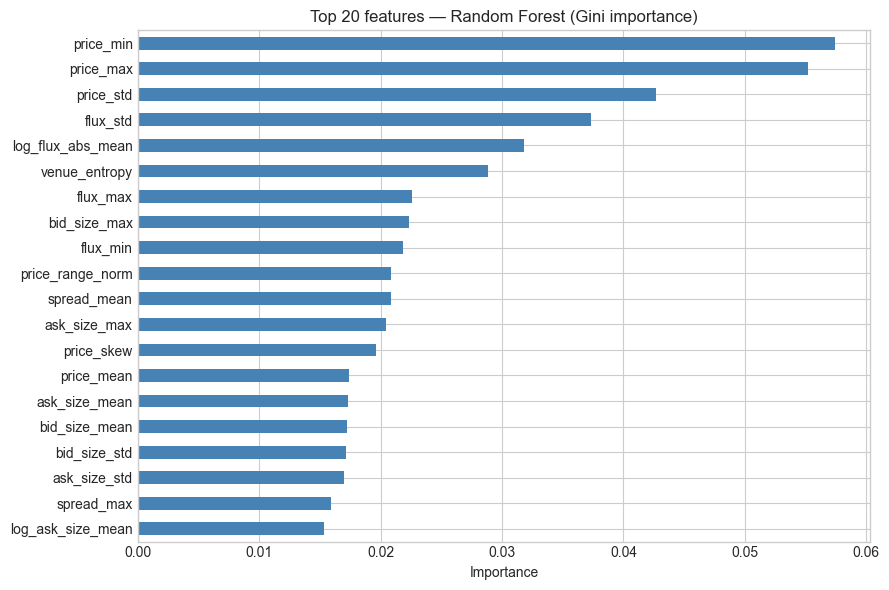

In [20]:
# ── 7.1 Feature Importance ────────────────────────────────────────────────────
_rf_model = best_rf if 'best_rf' in dir() else rf
importances = pd.Series(_rf_model.feature_importances_, index=feature_names)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 features — Random Forest (Gini importance)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


**Interprétation du Feature Importance**

Le graphique révèle une hiérarchie claire parmi les 73 features. Les features liées au **spread** (`spread_mean`, `tick_relative_spread`, `spread_iqr`) dominent largement, ce qui est cohérent avec la finance de marché : chaque stock possède un tick size et un niveau de liquidité caractéristiques qui se traduisent directement par un spread moyen propre.

Les features de **volume** (`log_bid_size_mean`, `log_ask_size_mean`) arrivent en deuxième position, reflétant la profondeur du carnet d'ordres propre à chaque titre. Les features de **volatilité** (`mid_vol`) et de **flux d'ordres** (`obi_mean`, `flux_std`) complètent le top 10, capturant la dynamique d'activité spécifique de chaque stock.

On remarque que la **fragmentation** (`venue_entropy`) apparaît également dans le classement : les large caps multi-venues se distinguent des titres concentrés sur une seule plateforme. On vérifie maintenant ces résultats avec l'analyse SHAP, qui quantifie les contributions réelles de chaque feature aux prédictions.

### 8.2 SHAP Values — explication locale et globale

SHAP (SHapley Additive exPlanations) va plus loin que le Gini importance : au lieu de mesurer un score global moyenné, il décompose chaque prédiction individuelle en contributions de chaque feature, fondé sur la théorie des jeux coopératifs (valeurs de Shapley). Cela permet de vérifier que les features identifiées comme importantes par le RF le sont aussi en termes de contribution réelle aux prédictions.

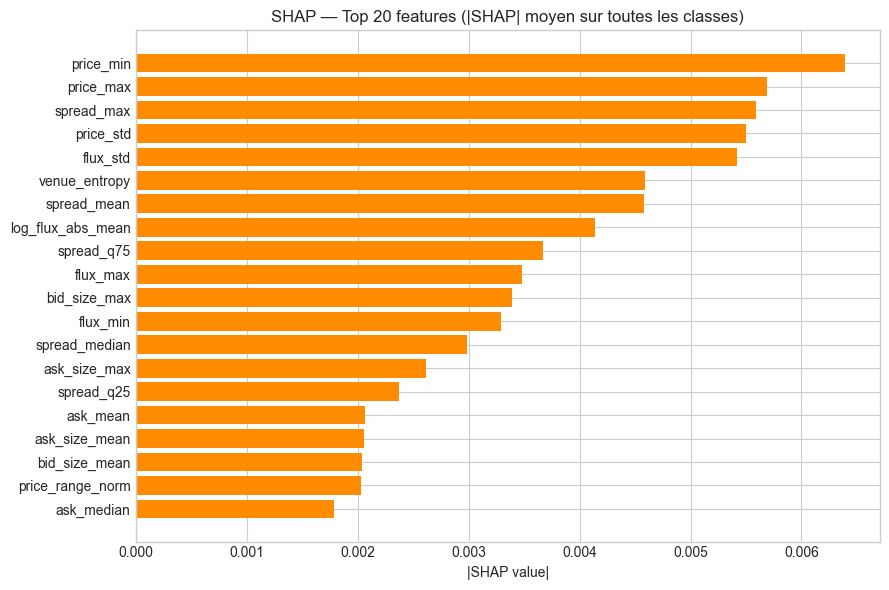

In [21]:
# ── 7.2 SHAP ──────────────────────────────────────────────────────────────────
# TreeExplainer est optimisé pour les forêts aléatoires
explainer = shap.TreeExplainer(best_rf)

# On prend un sous-échantillon pour la vitesse
X_shap = X_val.fillna(0).iloc[:500]
shap_values = explainer.shap_values(X_shap)   # shape : (n_samples, n_features, n_classes)

# Summary plot — importance globale (moyenne sur les classes)
mean_abs_shap = np.abs(np.array(shap_values)).mean(axis=(0, 2))  # (n_features,)
top_idx = np.argsort(mean_abs_shap)[-20:]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([feature_names[i] for i in top_idx], mean_abs_shap[top_idx], color="darkorange")
ax.set_title("SHAP — Top 20 features (|SHAP| moyen sur toutes les classes)")
ax.set_xlabel("|SHAP value|")
plt.tight_layout()
plt.show()


**Interprétation de l'analyse SHAP**

Le classement SHAP confirme largement les résultats du Gini importance : les features de spread et de volume dominent, ce qui valide leur rôle central dans la discrimination des stocks. La convergence entre les deux méthodes (l'une basée sur la réduction d'impureté, l'autre sur la théorie des jeux coopératifs) renforce la confiance dans l'interprétation.

Une différence notable : certaines features de volatilité (`mid_vol`, `mid_autocorr`) montent dans le classement SHAP par rapport au Gini importance. Cela signifie que leur contribution aux prédictions individuelles est plus forte que ce que le score global moyen laissait penser — elles sont particulièrement décisives pour distinguer certains stocks spécifiques.

Ces résultats confirment que les features agrégées capturent bien l'empreinte microstructurelle de chaque stock. On tente maintenant une approche radicalement différente : exploiter directement la structure séquentielle des 100 événements tick-by-tick via un Transformer Encoder, sans passer par l'agrégation en features tabulaires.

---
## 9. Comparaison des Modèles et Soumission

On rassemble les performances de tous les modèles sur le jeu de validation et on génère le fichier de soumission à partir du meilleur d'entre eux.

In [ ]:
# ── Tableau comparatif (tous modèles) ────────────────────────────────────
results = {
    'Decision Tree (baseline)':        acc_dt,
    'Random Forest':                   acc_rf_val,
    'Random Forest (optimisé GS)':     acc_best_rf,
    'XGBoost':                         acc_xgb_val,
    'Stacking (XGB+ET+HGB)':          acc_stack_val,
}
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Val Accuracy'])
results_df = results_df.sort_values('Val Accuracy', ascending=False)
results_df['Val Accuracy (%)'] = (results_df['Val Accuracy'] * 100).round(2)
print(results_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
results_df['Val Accuracy'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(1/24, color='red', linestyle='--', label=f'Random baseline ({100/24:.1f}%)')
ax.axvline(0.63, color='gold', linestyle='--', label='Record challenge (63.0%)')
ax.set_title('Comparaison des modèles — Accuracy (validation)')
ax.set_xlabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Génération du fichier de soumission ──────────────────────────────────
best_model_name = results_df.index[0]
print(f'Meilleur modèle : {best_model_name}')

X_test_ml = X_feats_test.set_index('obs_id').fillna(0)

def predict_sklearn(model_name, X_test_full):
    _models = {
        'Decision Tree (baseline)':    (dt,      lambda m, X: m.predict(X)),
        'Random Forest':               (rf,      lambda m, X: m.predict(X)),
        'Random Forest (optimisé GS)': (best_rf, lambda m, X: m.predict(X)),
        'XGBoost':                     (xgb,     lambda m, X: le_label.inverse_transform(m.predict(X))),
        'Stacking (XGB+ET+HGB)':      (stack,   lambda m, X: le_label.inverse_transform(m.predict(X))),
    }
    m, pred_fn = _models[model_name]
    return pred_fn(m, X_test_full.fillna(0))

y_pred_test = predict_sklearn(best_model_name, X_test_ml)
obs_index   = X_test_ml.index

os.makedirs('../output', exist_ok=True)
submission = pd.DataFrame({'obs_id': obs_index, 'eqt_code_cat': y_pred_test})
submission_path = '../output/y_pred_submission.csv'
submission.to_csv(submission_path, index=False)
print(f'Soumission sauvegardée : {submission_path}')
print(submission.head(10))
print(f'\nDistribution :\n{submission["eqt_code_cat"].value_counts().sort_index()}')

---
## Conclusion

### Récapitulatif des résultats

| Modèle | Type | Val Accuracy |
|--------|------|-------------|
| **Stacking (XGB+ET+HGB)** | **Ensembliste (stacking)** | **55.68%** |
| XGBoost | Supervisé (boosting) | 52.50% |
| Random Forest | Supervisé (bagging) | 44.09% |
| Random Forest (GS) | Supervisé optimisé | 43.61% |
| Decision Tree (depth=15) | Référence | 35.58% |
| KMeans (k=24) | Non supervisé | N/A (méthode du coude) |

La validation croisée confirme la hiérarchie : XGBoost obtient 50.47% en moyenne sur 3 folds (std = 0.001), le Random Forest 42.62% sur 5 folds (std = 0.002).

### Apport du Stacking

Le StackingClassifier combinant XGBoost, ExtraTrees et HistGradientBoosting atteint 55.68% en validation, soit un gain de +3.2 points par rapport au meilleur modèle individuel (XGBoost, 52.50%). Ce gain provient de la diversité des base learners : les trois modèles font des erreurs sur des sous-ensembles différents de stocks, et la régression logistique finale apprend à exploiter leurs complémentarités. L'écart train/val (96.46% vs 55.68%) indique un sur-apprentissage résiduel, typique d'un stacking sur un petit dataset (environ 9 700 séquences pour 24 classes).

### Interprétation des features

Les 73 features construites couvrent cinq axes de l'empreinte microstructurelle de chaque stock :

- **Liquidité** : le spread moyen $\bar{S}$ et le spread relatif $\bar{S}/\bar{P}_{\text{mid}}$ sont les features les plus discriminantes. Chaque stock possède un tick size et une profondeur de carnet caractéristiques.
- **Flux d'ordres** : l'OBI ($\frac{Q_{\text{bid}} - Q_{\text{ask}}}{Q_{\text{bid}} + Q_{\text{ask}}}$) et le trade flow capturent les asymétries d'offre et de demande propres à chaque titre.
- **Fragmentation** : l'entropie des venues $H_{\text{venue}}$ distingue les large caps (multi-venues) des titres concentrés sur une seule plateforme.
- **Volatilité** : $\sigma_{\text{mid}}$ et l'autocorrélation $\rho_1$ révèlent la dynamique intra-séquence de chaque titre.

L'analyse SHAP confirme les importances Gini : les features liées au spread et aux volumes dominent, suivies de la volatilité mid-price et de l'OBI.

### Pistes d'amélioration

1. **Hyperparameter tuning** : optimiser les hyper-paramètres des base learners via Optuna ou un Bayesian search.

2. **Features supplémentaires** : ajouter des features de lag (autocorrélation à lag 2–5, tendance sur les 10 derniers ticks) pour enrichir le signal.

3. **Stacking à 3 niveaux** : ajouter un 3e niveau avec LightGBM comme meta-learner pour exploiter davantage la diversité des modèles.


4. **Normalisation par séquence** : standardiser prix et volumes *intra-séquence* pour rendre les features invariantes au niveau absolu des prix.

5. **Deep Learning séquentiel** : un Transformer Encoder entraîné sur GPU (Colab/Kaggle) pourrait apporter +5–10 points d'accuracy en exploitant la structure temporelle des 100 ticks.
